# What governs the weighted residuals?


In [24]:
source("../RScripts/config.r")
source("../RScripts/plot_functions.r")
source("../RScripts/data_functions.r")
source("../RScripts/algo_functions.r")


options(repr.plot.width = 15, repr.plot.height = 10) # Adjust width & height


## 1) relative humidity -> SYNOP/TEMP

In [13]:
rh <- readRDS("../ens_data/rh_corr_map.rds")
str(rh)


List of 4
 $ correlation: num [1:241, 1:121] 0.008511 0.006914 0.002806 -0.000152 0.000011 ...
 $ lon        : num [1:241] -80 -79.5 -79 -78.5 -78 -77.5 -77 -76.5 -76 -75.5 ...
 $ lat        : num [1:121] 30 30.5 31 31.5 32 32.5 33 33.5 34 34.5 ...
 $ summary    :'data.frame':	3 obs. of  4 variables:
  ..$ spatial_aggregate: chr [1:3] "all" "land" "sea"
  ..$ q1               : num [1:3] -0.01139 -0.00868 -0.01327
  ..$ median           : num [1:3] -2.76e-04 -6.46e-04 -7.50e-06
  ..$ q3               : num [1:3] 0.00983 0.00612 0.01356


In [14]:
rh_df <- expand.grid(
    lon = rh$lon,
    lat = rh$lat
)

rh_df$corr <- as.vector(rh$correlation)
rh_df <- rh_df[, c("lat", "lon", "corr")]


In [4]:
GRAT_LAT <- seq(0, 90, 30)

p <- plot_spatial(
    data = rh_df, var_name = "corr",
    legend_name = "$r$",
    show_graticule_labels = FALSE,
    grid = NULL,
    use_diverging = TRUE
) + THEME_PUB +
    theme(
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks = element_blank(),
        legend.box.spacing = unit(0, "cm"), # Remove space between legend and plot
        legend.margin = margin(t = -.5, unit = "cm") # Adjust top margin if needed
    )


pdf 
  2

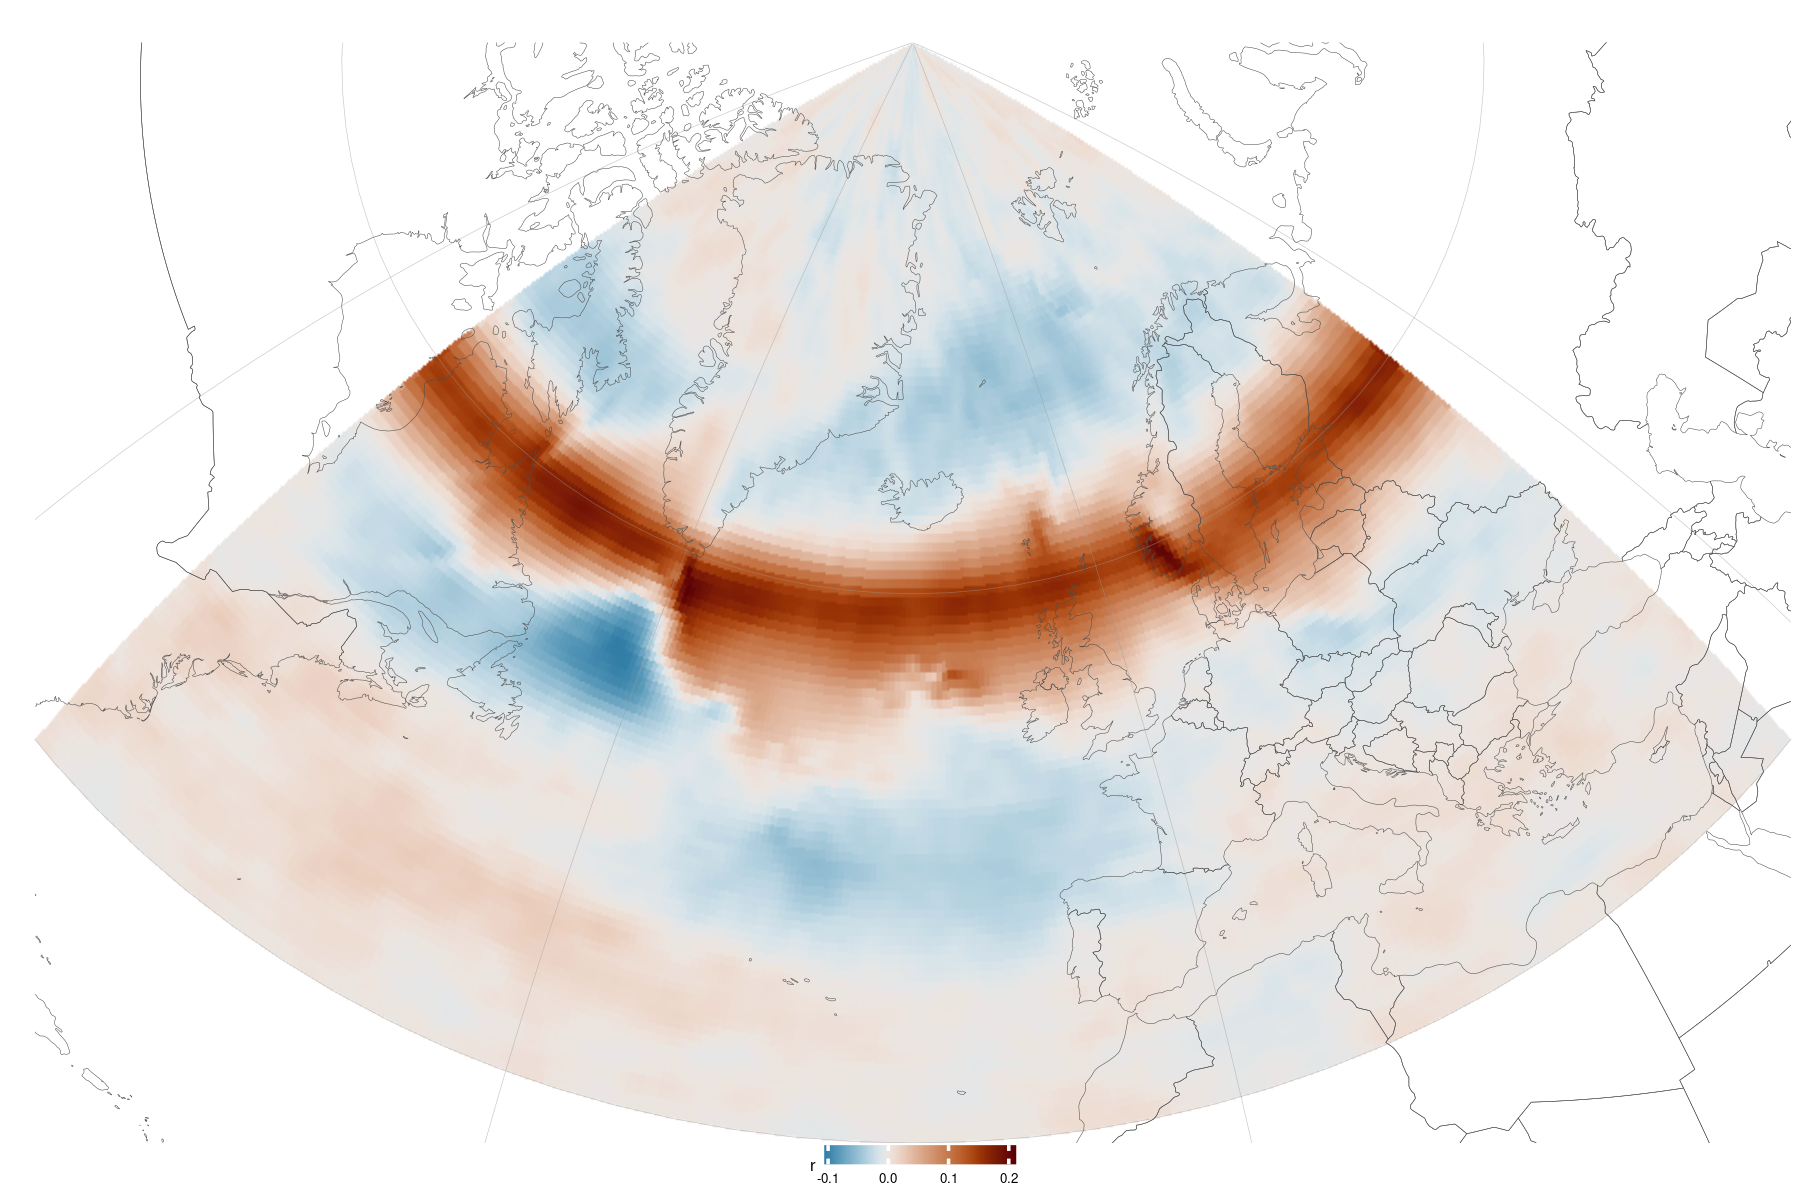

In [5]:
p
save_plot(p, "RHCorr", width = 3, height = 2.75)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Konvertierungsfehler für '59–60' in 'mbcsToSbcs': Punkt ersetzt <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Konvertierungsfehler für '59–60' in 'mbcsToSbcs': Punkt ersetzt <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Konvertierungsfehler für '59–60' in 'mbcsToSbcs': Punkt ersetzt <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Konvertierungsfehler für '58.5–60.5' in 'mbcsToSbcs': Punkt ersetzt <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Konvertierungsfehler für '58.5–60.5' in 'mbcsToSbcs': Punkt ersetzt <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Konvertierungsfehler für '58.5–60.5' in 'mbcsToSbcs': Punkt ersetzt <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), 

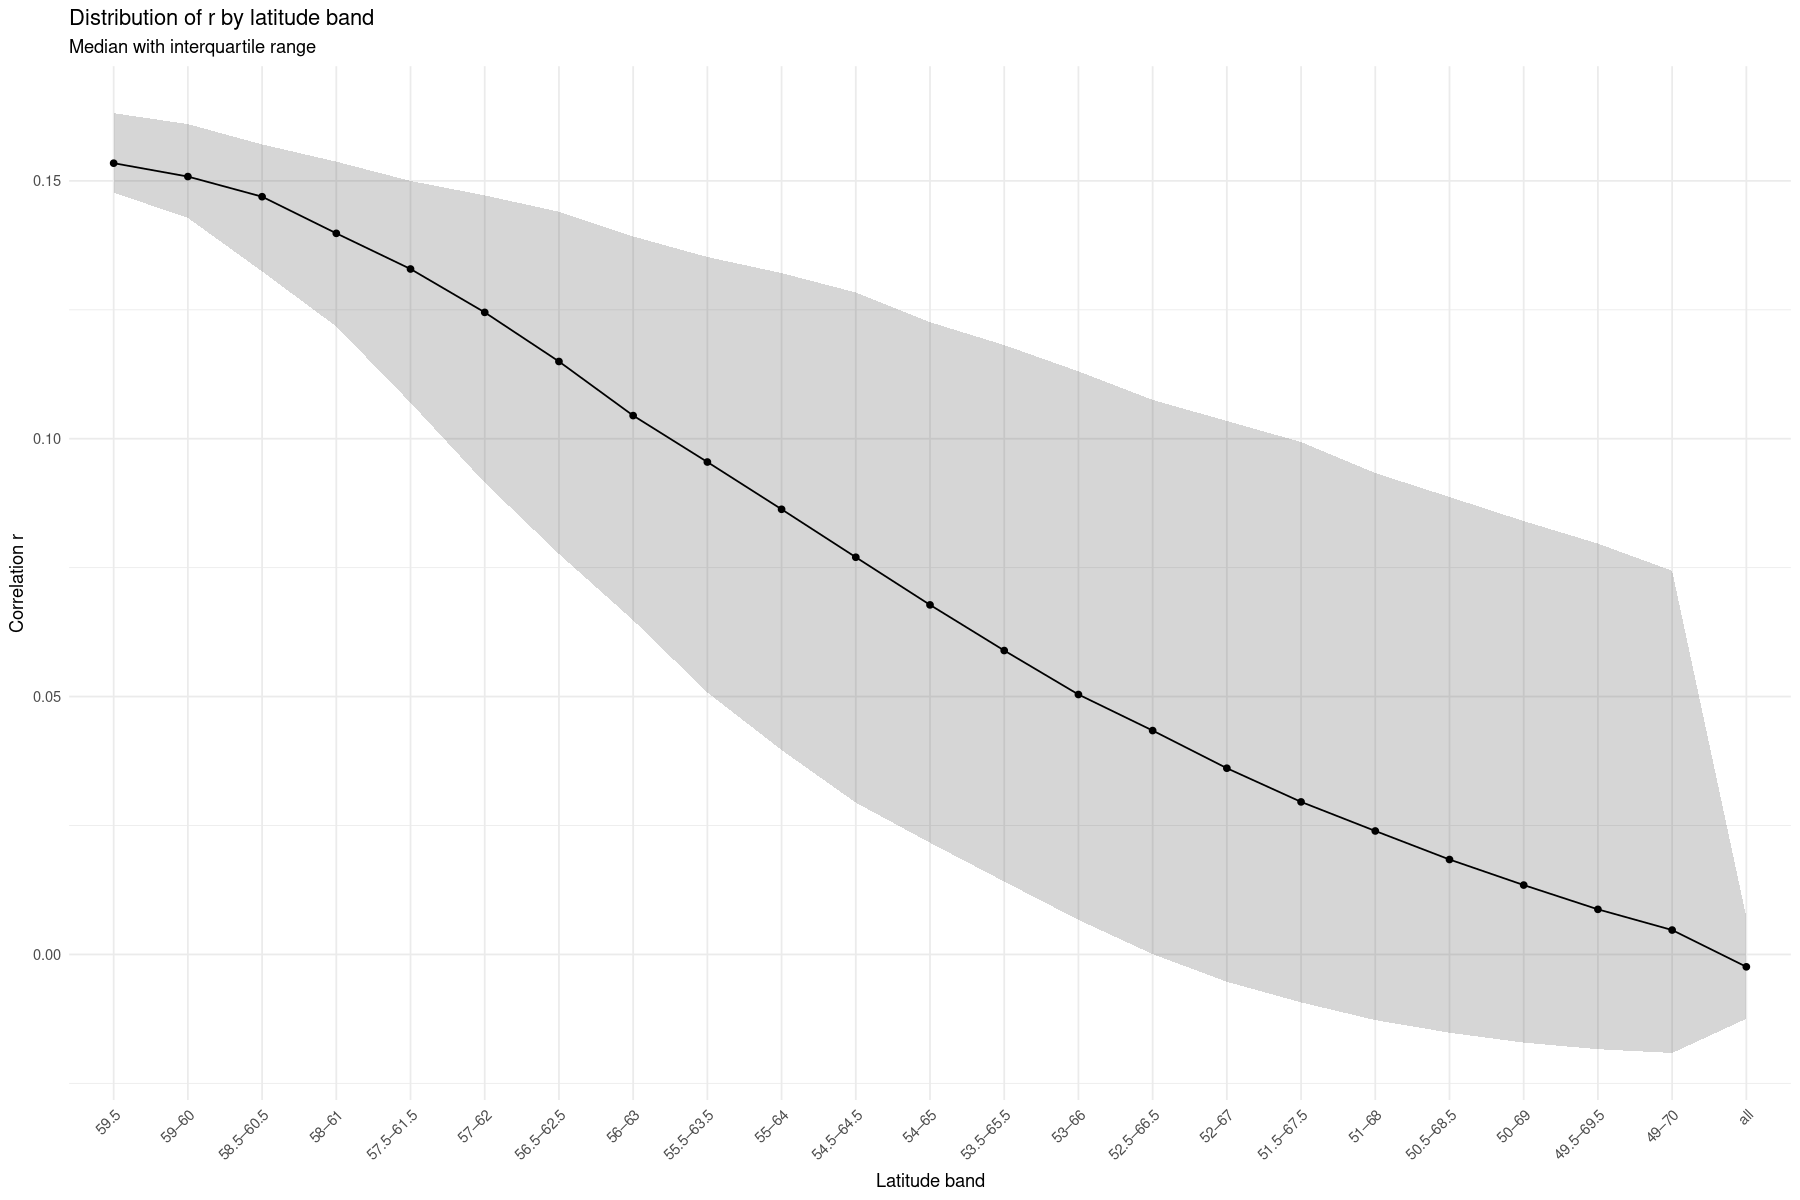

In [11]:
bands <- list(
    c(59.5, 59.5),
    c(59, 60),
    c(58.5, 60.5),
    c(58, 61),
    c(57.5, 61.5),
    c(57, 62),
    c(56.5, 62.5),
    c(56, 63),
    c(55.5, 63.5),
    c(55, 64),
    c(54.5, 64.5),
    c(54, 65),
    c(53.5, 65.5),
    c(53, 66),
    c(52.5, 66.5),
    c(52, 67),
    c(51.5, 67.5),
    c(51, 68),
    c(50.5, 68.5),
    c(50, 69),
    c(49.5, 69.5),
    c(49, 70),
    c(-Inf, Inf)
)

band_label <- function(x) {
    if (is.infinite(x[1]) && is.infinite(x[2])) {
        return("all")
    }
    if (x[1] == x[2]) {
        return(as.character(x[1]))
    }
    paste0(x[1], "–", x[2])
}

summ <- map_dfr(bands, function(b) {
    d <- rh_df %>% filter(lat >= b[1], lat <= b[2], is.finite(corr))
    qs <- quantile(d$corr, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
    tibble(
        band = band_label(b),
        q1 = qs[[1]],
        median = qs[[2]],
        q3 = qs[[3]],
        n = nrow(d)
    )
})

summ$band <- factor(summ$band, levels = summ$band)

ggplot(summ, aes(x = band, y = median, group = 1)) +
    geom_ribbon(aes(ymin = q1, ymax = q3), alpha = 0.2) +
    geom_line() +
    geom_point() +
    labs(
        x = "Latitude band",
        y = "Correlation r",
        title = "Distribution of r by latitude band",
        subtitle = "Median with interquartile range"
    ) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))


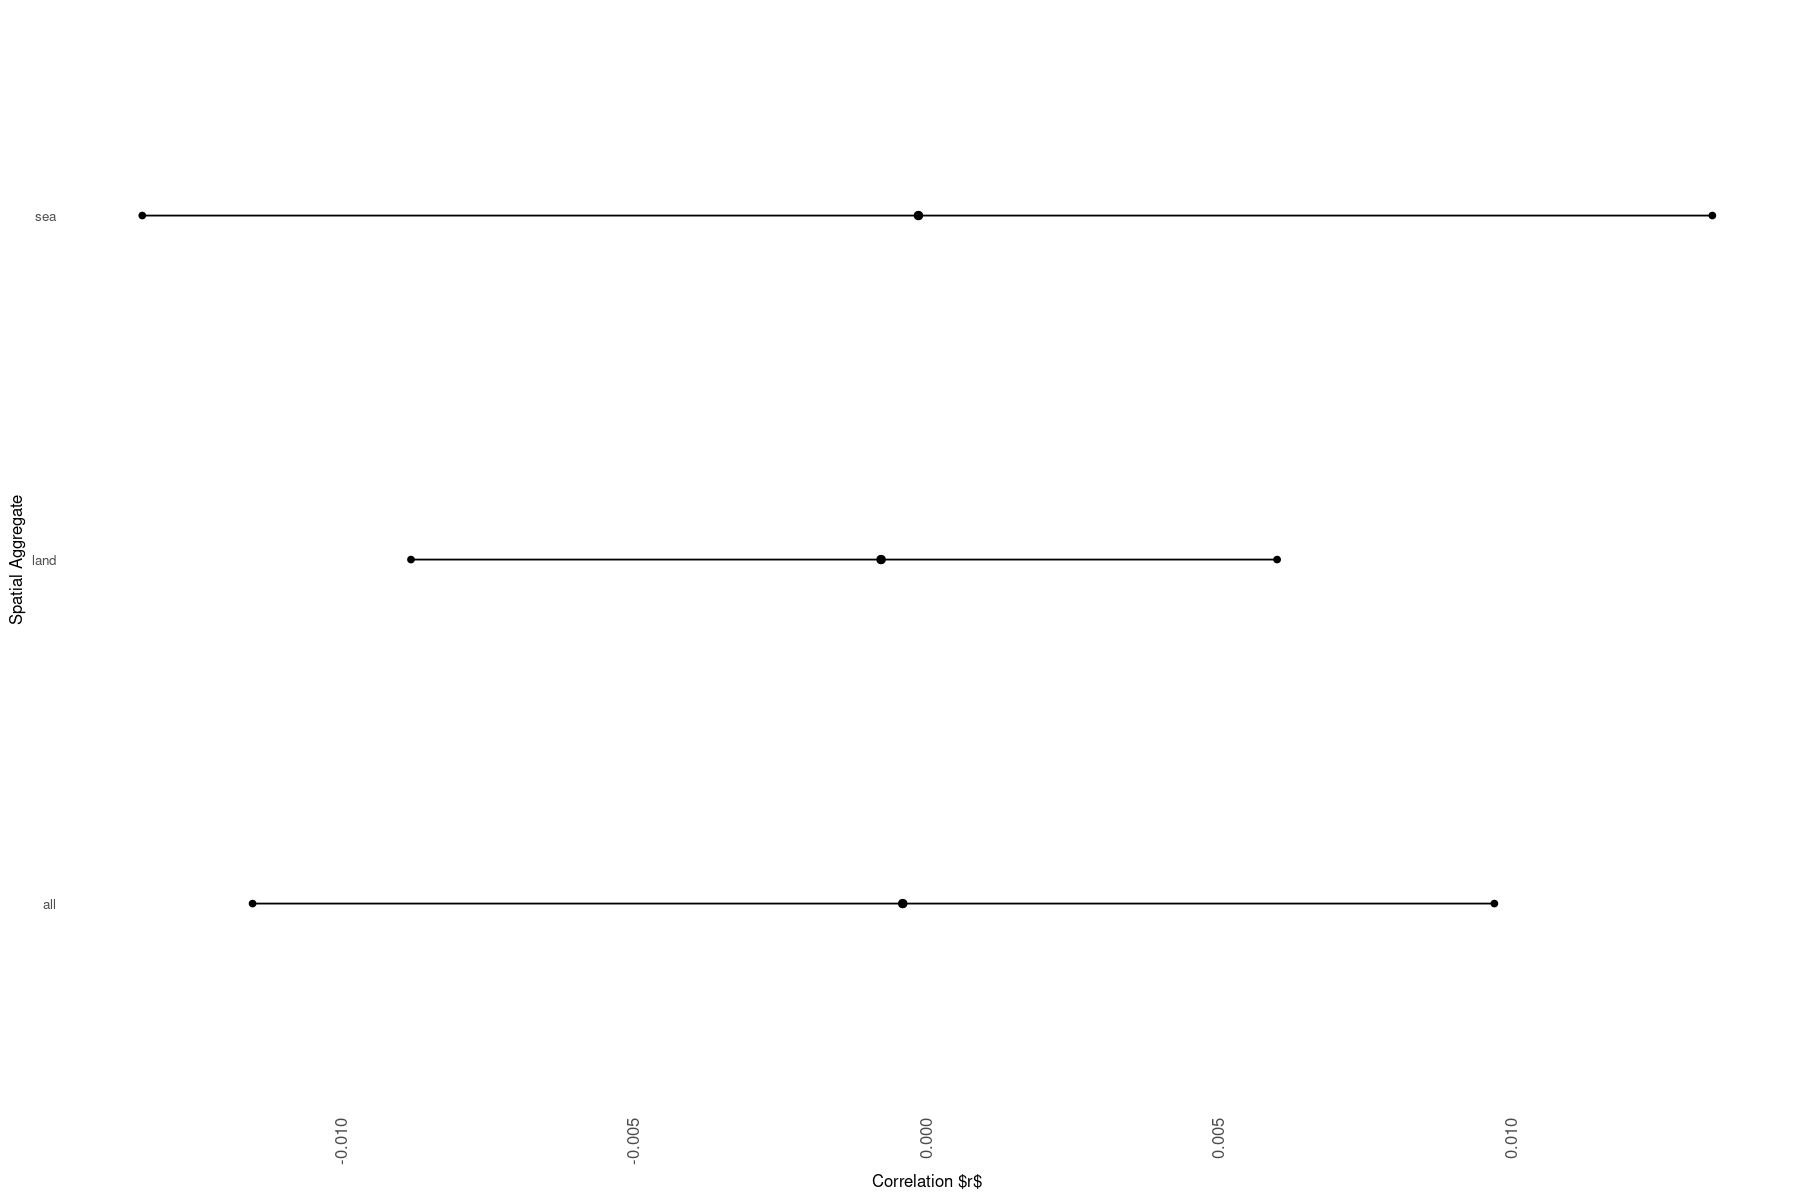

In [11]:
ggplot(rh$summary, aes(x = spatial_aggregate)) +
    geom_linerange(aes(ymin = q1, ymax = q3)) +
    geom_point(aes(y = q1)) +
    geom_point(aes(y = median), size = 2) +
    geom_point(aes(y = q3)) +
    coord_flip() +
    labs(x = "Spatial Aggregate", y = "Correlation $r$") +
    THEME_PUB


In [15]:
rh_yearly <- readRDS("../ens_data/rh_corr.rds")


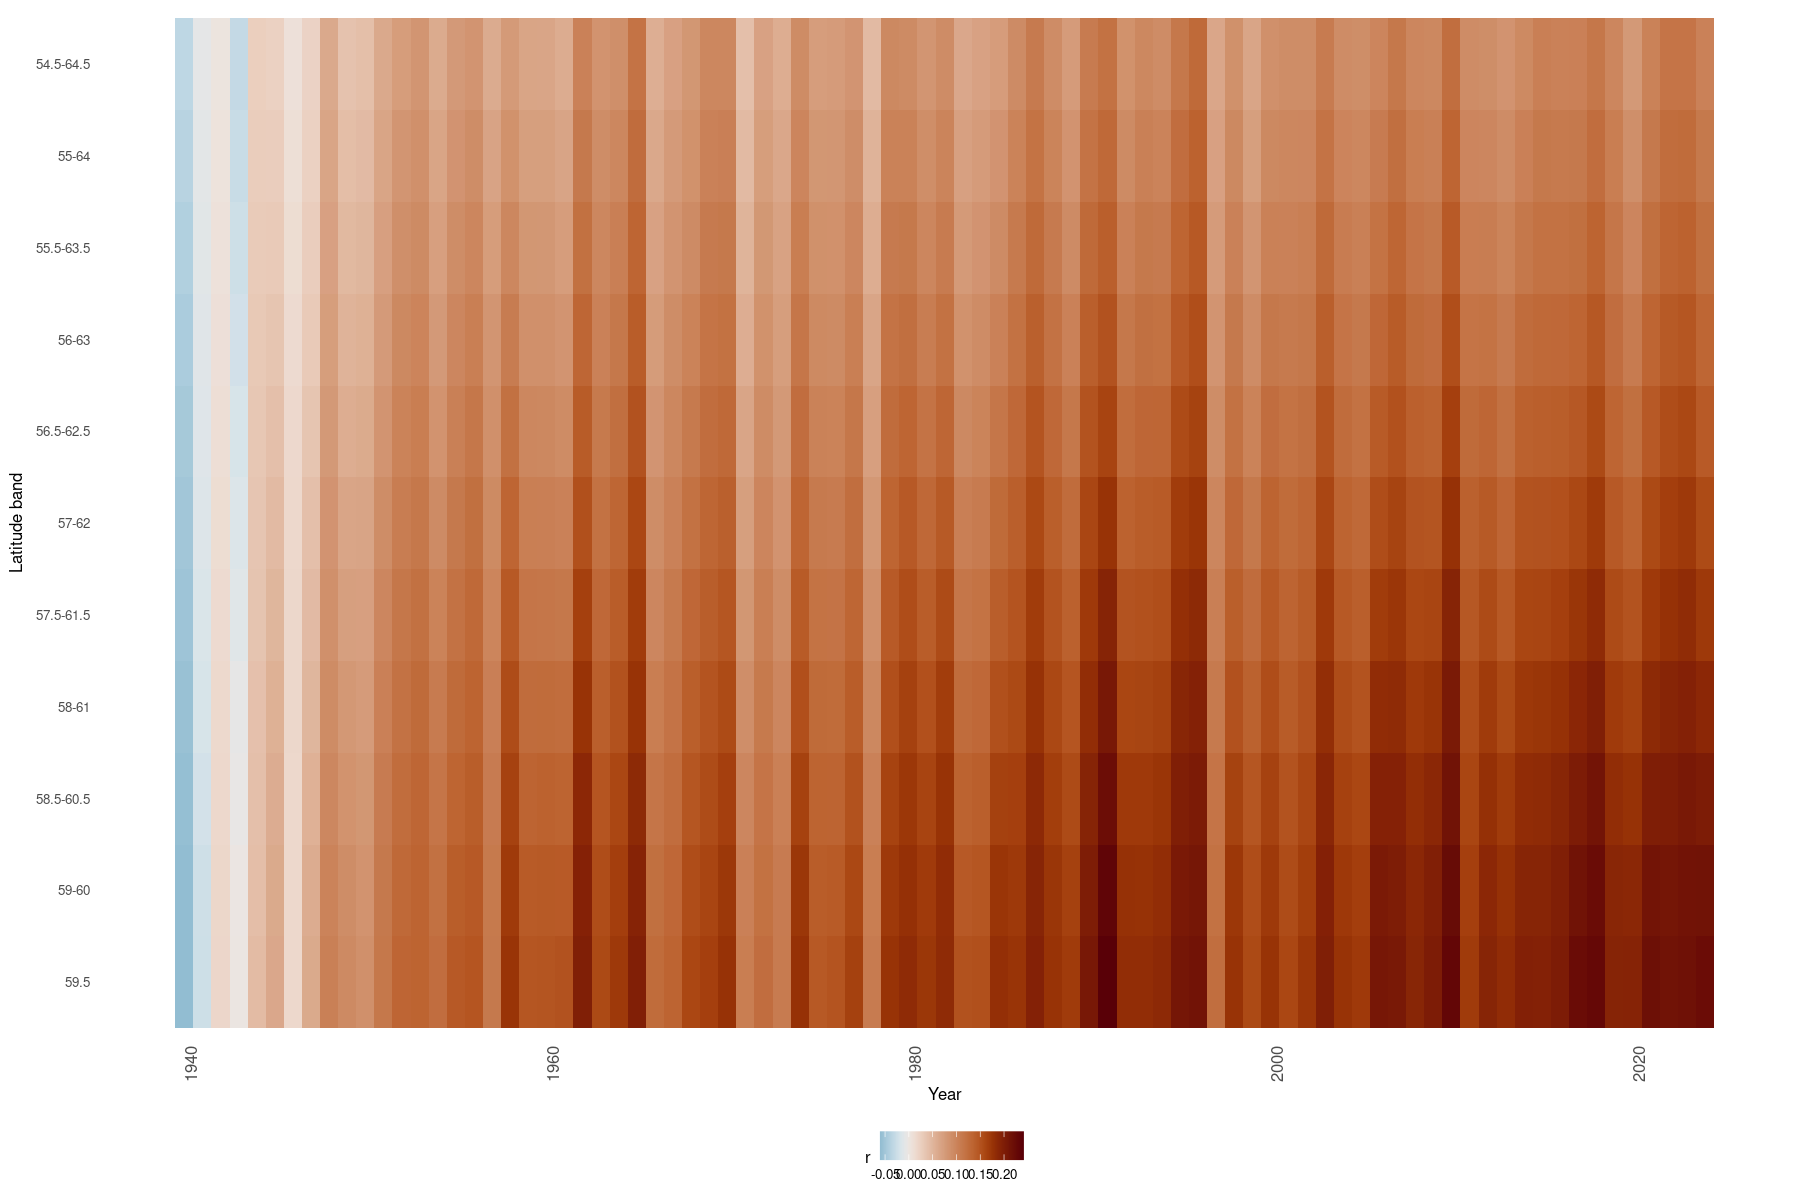

In [18]:
df_plot <- rh_yearly %>%
    mutate(
        band = factor(
            band,
            levels = unique(band)
        )
    )

ggplot(df_plot, aes(x = year, y = band, fill = r)) +
    geom_tile() +
    get_diverging_scale() +
    labs(
        x = "Year",
        y = "Latitude band",
        fill = "r"
    ) +
    THEME_PUB


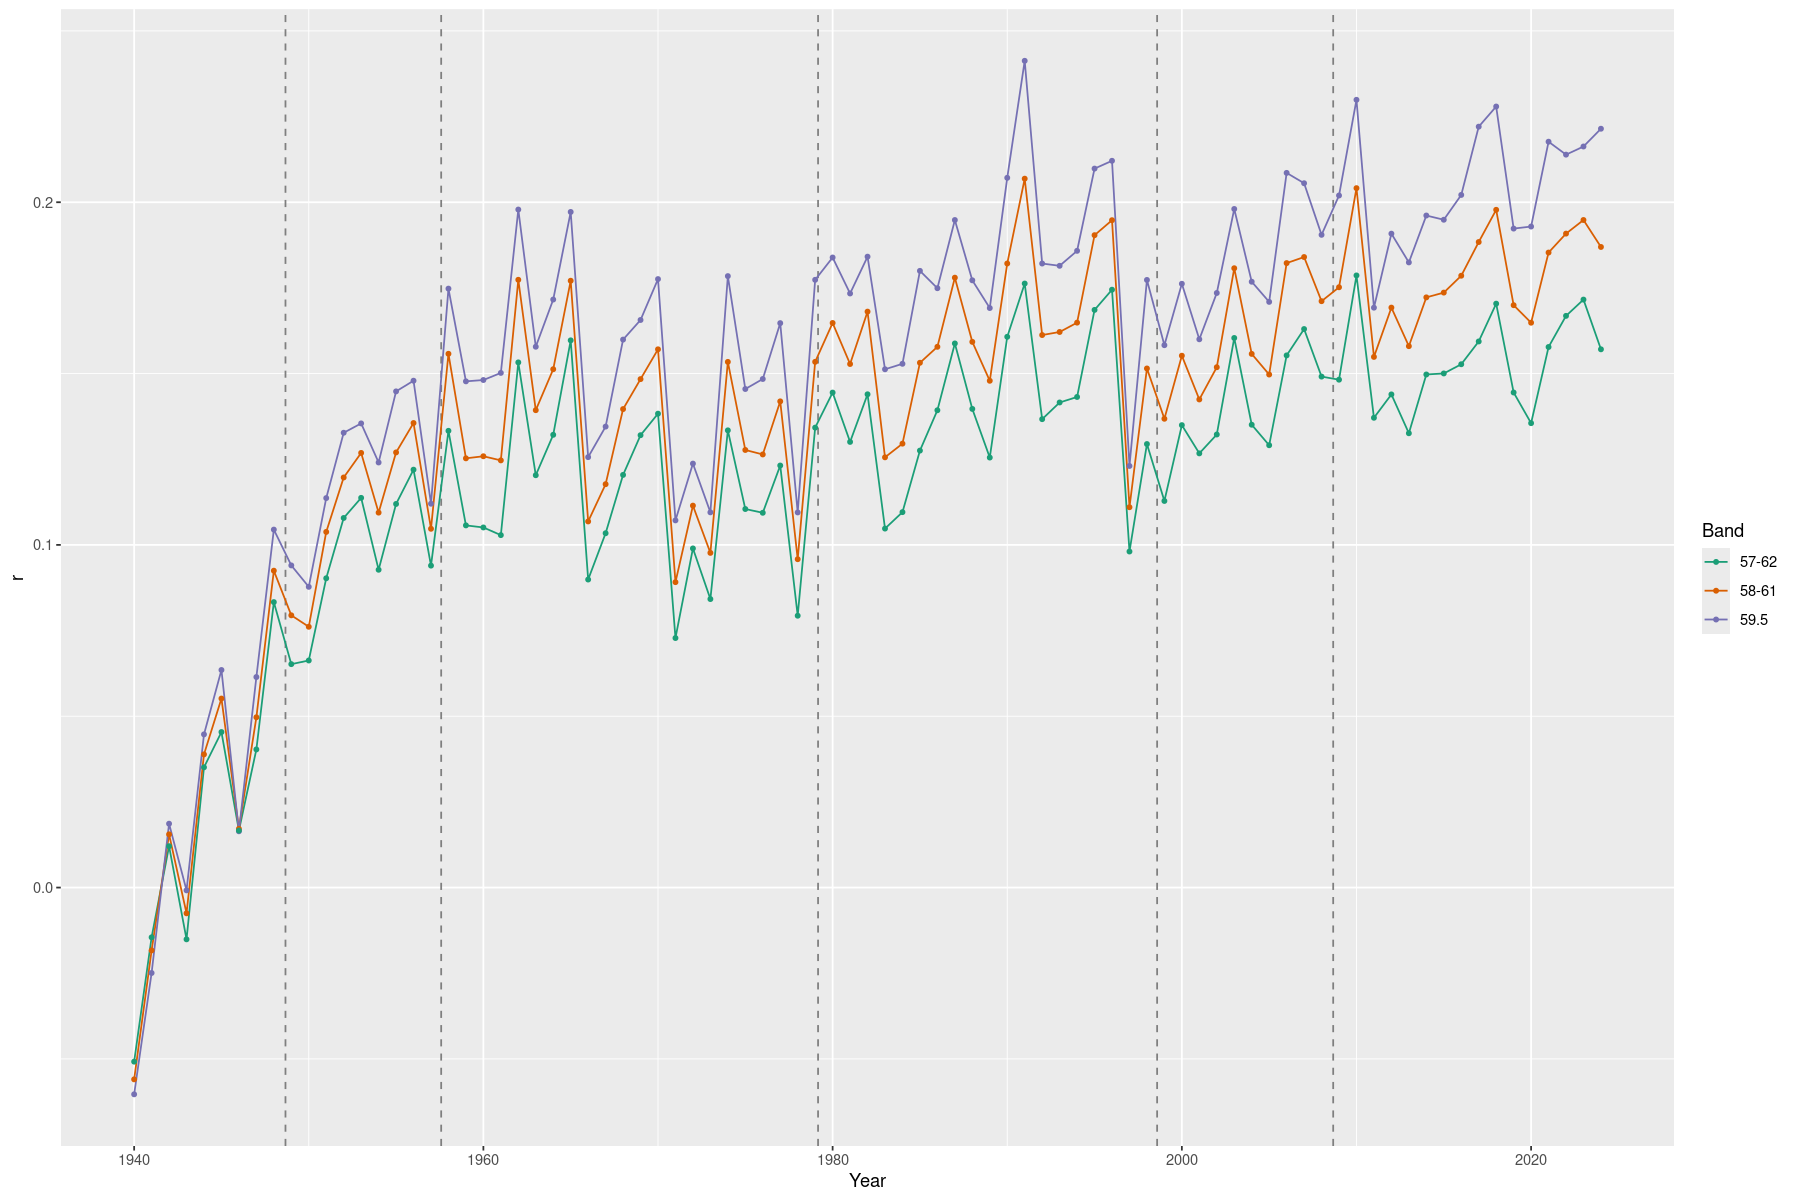

In [23]:
bands_keep <- c("59.5", "58-61", "57-62")
cp_dates <- as.Date(paste0(CP, "-01"))
cp_years <- as.numeric(format(cp_dates, "%Y")) + (as.numeric(format(cp_dates, "%m")) - 1) / 12

df_plot <- rh_yearly %>%
    filter(band %in% bands_keep)

ggplot(df_plot, aes(x = year, y = r, color = band)) +
    geom_vline(xintercept = cp_years, linetype = "dashed", color = "grey50") +
    geom_line() +
    geom_point(size = 1) +
    labs(
        x = "Year",
        y = "r",
        color = "Band"
    ) +
    get_categorical_scale() #+
# THEME_PUB


## 2) Hydrometeors -> Microwave

In [12]:
hydro <- readRDS("../ens_data/hydro_corr_yearly.rds")


In [13]:
str(hydro)


List of 1
 $ summary:'data.frame':	255 obs. of  5 variables:
  ..$ year             : int [1:255] 1940 1940 1940 1941 1941 1941 1942 1942 1942 1943 ...
  ..$ median           : num [1:255] -0.000855 0.007688 -0.004449 -0.008629 -0.009117 ...
  ..$ q1               : num [1:255] -0.0452 -0.0361 -0.0498 -0.0516 -0.0489 ...
  ..$ q3               : num [1:255] 0.0432 0.0561 0.0377 0.0351 0.0357 ...
  ..$ spatial_aggregate: chr [1:255] "all" "land" "sea" "all" ...


pdf 
  2

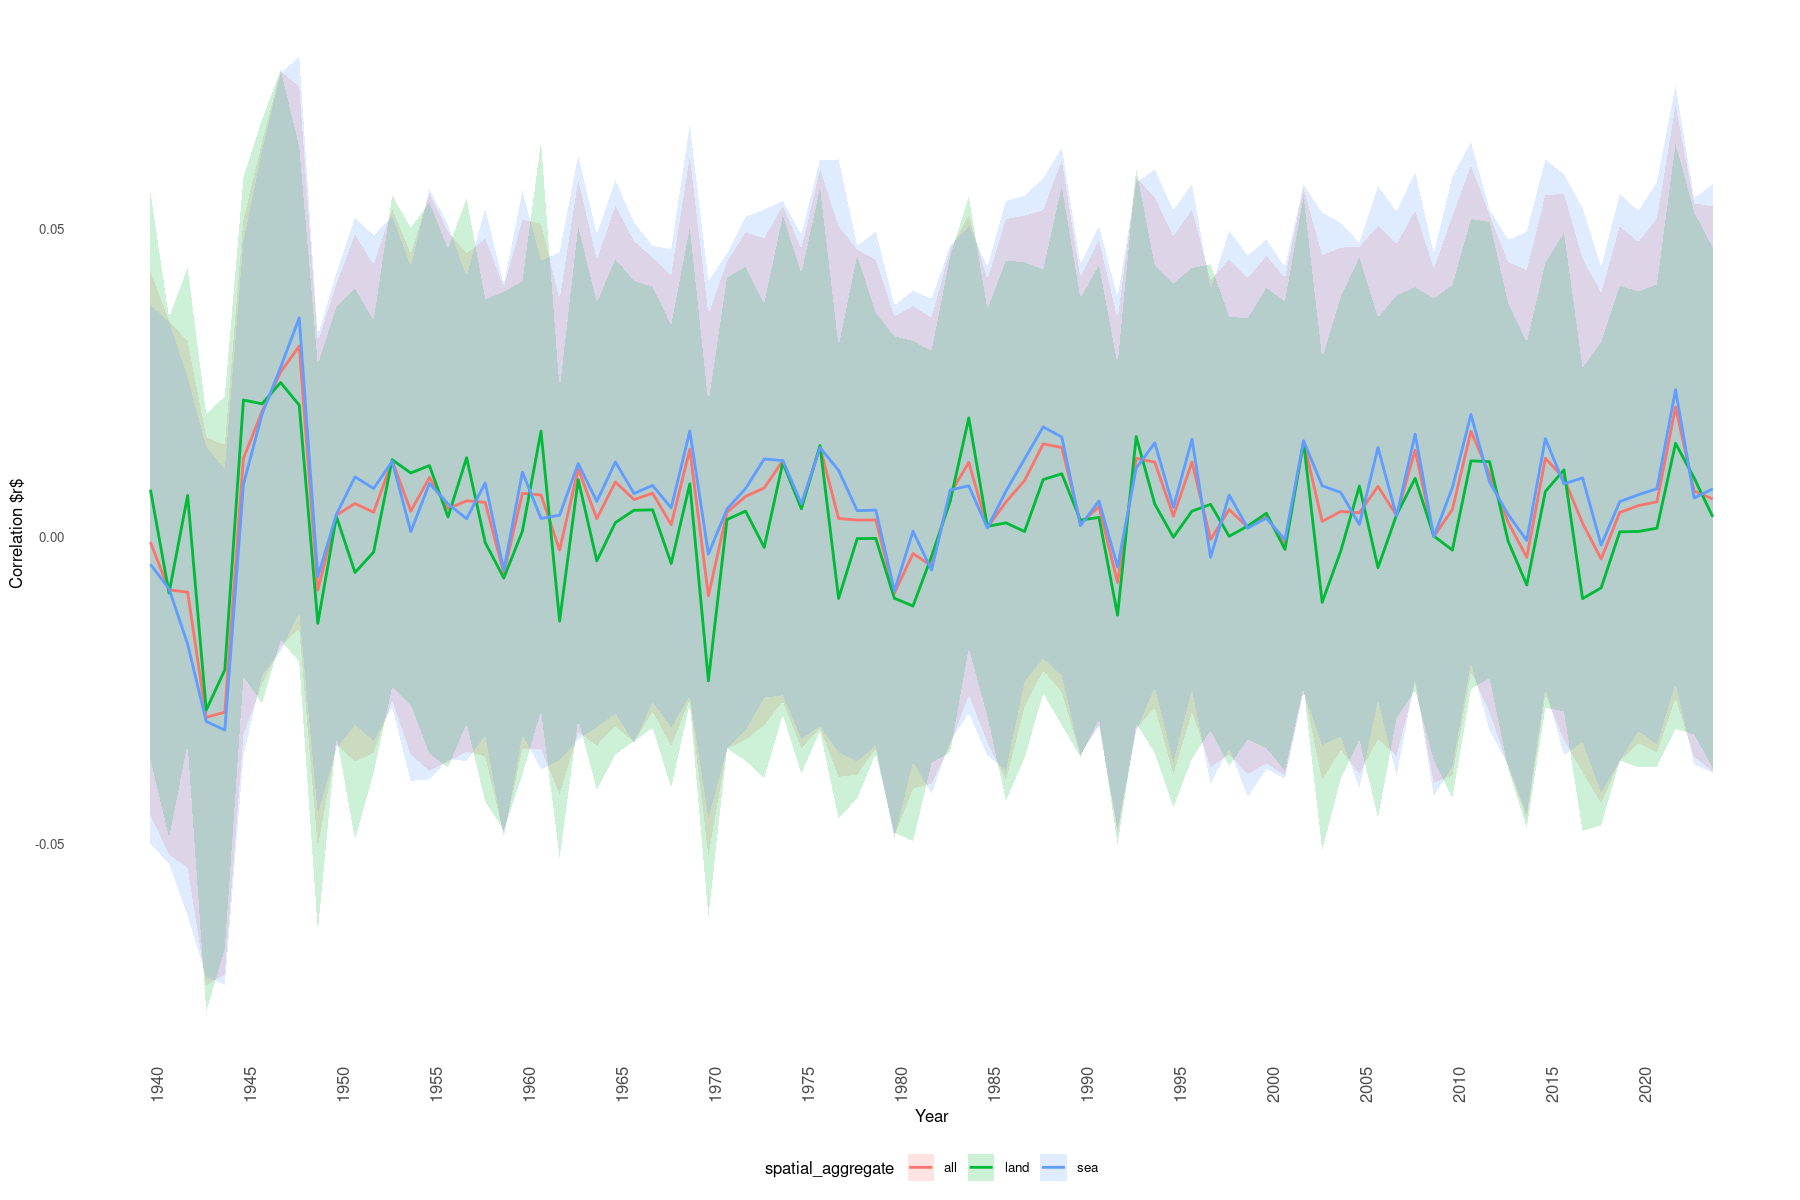

In [17]:
p <- ggplot(hydro$summary, aes(x = year, color = spatial_aggregate, fill = spatial_aggregate)) +
    geom_ribbon(aes(ymin = q1, ymax = q3), alpha = 0.2, color = NA) +
    geom_line(aes(y = median), linewidth = 0.8) +
    scale_x_continuous(breaks = seq(min(hydro$summary$year), max(hydro$summary$year), by = 5)) +
    labs(x = "Year", y = "Correlation $r$") +
    THEME_PUB

p
save_plot(p, "hydro_corr_yearly.pdf", width = 5.5, height = 4)


## All kinds of variables:

In [29]:
path <- paste0(ENS_DATA_DIR, "corr_maps/")

# find all files matching *_corr_map.rds
files <- list.files(path, pattern = "_corr_map\\.rds$", full.names = TRUE)


files <- list.files(path, pattern = "_corr_map\\.rds$", full.names = TRUE)

combined_df <- map(files, function(f) {
    x <- readRDS(f)

    # remove only the final suffix, keep all underscores in the variable name
    varname <- sub("_corr_map\\.rds$", "", basename(f))

    expand.grid(lon = x$lon, lat = x$lat) %>%
        mutate(!!varname := as.vector(x$correlation))
}) %>%
    reduce(full_join, by = c("lon", "lat")) %>%
    select(lat, lon, everything())

str(combined_df)


'data.frame':	29161 obs. of  17 variables:
 $ lat          : num  30 30 30 30 30 30 30 30 30 30 ...
 $ lon          : num  -80 -79.5 -79 -78.5 -78 -77.5 -77 -76.5 -76 -75.5 ...
 $ eady         : num  0.0922 0.095 0.0991 0.1032 0.1048 ...
 $ hcc          : num  0.175 0.181 0.184 0.188 0.191 ...
 $ hydrosum     : num  0.262 0.274 0.282 0.289 0.287 ...
 $ mcc          : num  0.234 0.239 0.249 0.265 0.264 ...
 $ rh_700_850   : num  0.223 0.233 0.245 0.253 0.257 ...
 $ upper_wind   : num  0.0961 0.0993 0.1014 0.1027 0.1018 ...
 $ wcb_asc_12utc: num  0.221 NA 0.235 NA 0.234 ...
 $ wcb_asc_lag12: num  0.119 NA 0.118 NA 0.133 ...
 $ wcb_asc_lag24: num  0.0335 NA 0.0334 NA 0.0518 ...
 $ wcb_in_12utc : num  0.211 NA 0.211 NA 0.206 ...
 $ wcb_in_lag12 : num  0.182 NA 0.187 NA 0.192 ...
 $ wcb_in_lag24 : num  0.0774 NA 0.088 NA 0.1027 ...
 $ wcb_out_12utc: num  0.161 NA 0.171 NA 0.17 ...
 $ wcb_out_lag12: num  0.117 NA 0.124 NA 0.127 ...
 $ wcb_out_lag24: num  0.0644 NA 0.0766 NA 0.0874 ...
 - att

In [33]:
names(combined_df)[-(1:2)]


[1] "eady"          "hcc"           "hydrosum"      "mcc"          
 [5] "rh_700_850"    "upper_wind"    "wcb_asc_12utc" "wcb_asc_lag12"
 [9] "wcb_asc_lag24" "wcb_in_12utc"  "wcb_in_lag12"  "wcb_in_lag24" 
[13] "wcb_out_12utc" "wcb_out_lag12" "wcb_out_lag24"

In [38]:
vars <- setdiff(names(combined_df), c("lat", "lon"))
for (var in vars) {
    print(var)
    p <- rlang::inject(plot_map(combined_df, !!rlang::sym(var), var))
    print(p)
}


[1] "eady"


although coordinates are longitude/latitude, st_union assumes that they are
planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


ERROR: [1m[33mError[39m in `dplyr::pull()`:[22m
[33m![39m Can't extract columns that don't exist.
[31m✖[39m Column `var` doesn't exist.
